In [1]:
import pandas as pd
import numpy as np
import keras
import tensorflow as tf

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [2]:
dataset_df = pd.read_csv('../dataset/open-meteo_newDataset.csv')

In [3]:
dataset_df.head()

,time,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),rain (mm),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),et0_fao_evapotranspiration (mm),vapour_pressure_deficit (kPa),shortwave_radiation_instant (W/m²),direct_radiation_instant (W/m²),diffuse_radiation_instant (W/m²),direct_normal_irradiance_instant (W/m²),terrestrial_radiation_instant (W/m²)
0,2019-01-23T00:00,10.1,84,7.4,8.2,0.0,5,4,2,0,0.0,0.20,0.0,0.0,0.0,0.0,0.0
1,2019-01-23T01:00,9.7,84,7.2,7.7,0.0,4,4,1,0,0.0,0.19,0.0,0.0,0.0,0.0,0.0
2,2019-01-23T02:00,9.6,84,7.0,7.5,0.0,10,10,2,0,0.0,0.19,0.0,0.0,0.0,0.0,0.0
3,2019-01-23T03:00,9.6,84,7.0,7.5,0.0,29,29,4,0,0.0,0.19,0.0,0.0,0.0,0.0,0.0
4,2019-01-23T04:00,10.3,81,7.1,8.4,0.0,35,34,6,0,0.0,0.24,0.0,0.0,0.0,0.0,0.0


In [4]:
dataset_df.columns

Index(['time', 'temperature_2m (°C)', 'relative_humidity_2m (%)',
       'dew_point_2m (°C)', 'apparent_temperature (°C)', 'rain (mm)',
       'cloud_cover (%)', 'cloud_cover_low (%)', 'cloud_cover_mid (%)',
       'cloud_cover_high (%)', 'et0_fao_evapotranspiration (mm)',
       'vapour_pressure_deficit (kPa)', 'shortwave_radiation_instant (W/m²)',
       'direct_radiation_instant (W/m²)', 'diffuse_radiation_instant (W/m²)',
       'direct_normal_irradiance_instant (W/m²)',
       'terrestrial_radiation_instant (W/m²)'],
      dtype='object')

In [5]:
dataset_df['time'] = pd.to_datetime(dataset_df['time'])
dataset_df['month'] = dataset_df['time'].dt.month

# Pisahkan data berdasarkan bulan
january_df = dataset_df[dataset_df['month'] == 1]
february_df = dataset_df[dataset_df['month'] == 2]
march_df = dataset_df[dataset_df['month'] == 3]
april_df = dataset_df[dataset_df['month'] == 4]
may_df = dataset_df[dataset_df['month'] == 5]
june_df = dataset_df[dataset_df['month'] == 6]
july_df = dataset_df[dataset_df['month'] == 7]
august_df = dataset_df[dataset_df['month'] == 8]
september_df = dataset_df[dataset_df['month'] == 9]
october_df = dataset_df[dataset_df['month'] == 10]
november_df = dataset_df[dataset_df['month'] == 11]
december_df = dataset_df[dataset_df['month'] == 12]

In [6]:
january_df.set_index('time', inplace=True)
february_df.set_index('time', inplace=True)
march_df.set_index('time', inplace=True)
april_df.set_index('time', inplace=True)
may_df.set_index('time', inplace=True)
june_df.set_index('time', inplace=True)
july_df.set_index('time', inplace=True)
august_df.set_index('time', inplace=True)
september_df.set_index('time', inplace=True)
october_df.set_index('time', inplace=True)
november_df.set_index('time', inplace=True)
december_df.set_index('time', inplace=True)

# January

## Preprocessing

In [7]:
data_features = january_df[['shortwave_radiation_instant (W/m²)', 'direct_radiation_instant (W/m²)',
       'direct_normal_irradiance_instant (W/m²)', 'diffuse_radiation_instant (W/m²)', 'et0_fao_evapotranspiration (mm)', 'cloud_cover (%)',
       'terrestrial_radiation_instant (W/m²)']].values

data_target = january_df['shortwave_radiation_instant (W/m²)'].values

In [8]:
print(len(data_features))

240


In [9]:
look_back = 24 #menggunakan timestamp 24
n_ahead = 12 # predict 24 jam berikutnya

x_seq = []
y_seq = []

for i in range(len(data_features) - look_back - n_ahead + 1):
    x_seq.append(data_features[i : (i + look_back)]) # mengambil value 24 jam sebelum
    y_seq.append(data_target[(i + look_back) : (i + look_back + n_ahead)]) #mengambil value 24 jam berikutnya

x_seq, y_seq = np.array(x_seq), np.array(y_seq)

In [10]:
print(x_seq.shape)
print(y_seq.shape)

(205, 24, 7)
(205, 12)


In [11]:
split_point = int(len(x_seq) * 0.8) # 80% for training and 20% for testing

x_train, x_test = x_seq[:split_point], x_seq[split_point:]
y_train, y_test = y_seq[:split_point], y_seq[split_point:]

#flatten the y

y_train = y_train.flatten()
y_test = y_test.flatten()

print(f'x_train shape: {x_train.shape}, x_test shape: {x_test.shape}')
print(f'y_train shape: {y_train.shape}, y_test shape: {y_test.shape}')

x_train shape: (164, 24, 7), x_test shape: (41, 24, 7)
y_train shape: (1968,), y_test shape: (492,)


In [12]:
from sklearn.preprocessing import StandardScaler, RobustScaler

scaler_x = RobustScaler()
scaler_y = RobustScaler()

#fit dan transform the training data
#kalau mau fit transform, data harus 2 dimensi. untuk x, kembalikan ke 3 dimensi. untuk y, kembalikan 1 dimensi
x_train_scaled = scaler_x.fit_transform(x_train.reshape(-1, x_train.shape[2])).reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2]) 
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, n_ahead))
# y_train_scaled = y_train_scaled.flatten()

# tranform the testing data
x_test_scaled = scaler_x.fit_transform(x_test.reshape(-1, x_train.shape[2])).reshape(x_test.shape[0], x_test.shape[1], x_train.shape[2])
y_test_scaled = scaler_y.transform(y_test.reshape(-1, n_ahead))
# y_test_scaled = y_test_scaled.flatten()

# # Reshape X_train and X_test to 3D for LSTM input (samples, time steps, features)
# X_train_scaled = X_train.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
# X_test_scaled = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# Check the shapes after standardization
print(f'X_train_scaled shape: {x_train_scaled.shape}, X_test_scaled shape: {x_test_scaled.shape}')
print(f'y_train_scaled shape: {y_train_scaled.shape}, y_test_scaled shape: {y_test_scaled.shape}')

X_train_scaled shape: (164, 24, 7), X_test_scaled shape: (41, 24, 7)
y_train_scaled shape: (164, 12), y_test_scaled shape: (41, 12)


## Build Model

In [13]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Attention and Normalization
    x = keras.layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(inputs, inputs)
    x = keras.layers.Dropout(dropout)(x)
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs

    # Feed Forward Part
    x = keras.layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(res)
    x = keras.layers.Dropout(dropout)(x)
    x = keras.layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x)
    return x + res

In [14]:
class ExpandDims(keras.layers.Layer):
    def __init__(self, axis, **kwargs):
        super(ExpandDims, self).__init__(**kwargs)
        self.axis = axis

    def call(self, inputs):
        return tf.expand_dims(inputs, axis=self.axis)

In [15]:
def build_model(
    n_input,
    n_output,
    num_features,
    head_size,
    num_heads,
    ff_dim,
    num_transformer_blocks,
    mlp_units,
    dropout=0,
    mlp_dropout=0,
):
    inputs = keras.Input(shape=(n_input, num_features))
    x = inputs
    x = keras.layers.LSTM(units=128, name="lstm_encoder_hidden", return_sequences=True, 
                        kernel_initializer='he_normal')(x)
    x = keras.layers.LSTM(units=128, name="lstm_encoder_hidden2", return_sequences=True)(x)
    x = keras.layers.Dropout(0.2)(x)
    #
    x = keras.layers.LSTM(units=128, name="lstm_encoder_hidden3", return_sequences=True)(x)
    x = keras.layers.LSTM(units=128, name="lstm_encoder_hidden4", return_sequences=True)(x)
    x = keras.layers.Dropout(0.2)(x)
    # x = keras.layers.LSTM(units=128, name="lstm_encoder_hidden4", return_sequences=True)(x)
    # x = keras.layers.Dropout(0.2)(x)
    # x = keras.layers.LSTM(units=128, name="lstm_encoder_hidden5", return_sequences=True)(x)
    # x = keras.layers.Dropout(0.2)(x)
    #
    x, state_h, state_c = keras.layers.LSTM(units=128, return_state=True, return_sequences=True, 
                                          name="lstm_encoder")(x)
    
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    x = keras.layers.GlobalAveragePooling1D(data_format="channels_last")(x)
    x = ExpandDims(axis=1)(x)
    
    x = keras.layers.LSTM(units=128, return_sequences=True, name="lstm_decoder")(x, initial_state=[state_h, state_c])    
    x = keras.layers.LSTM(units=128, name="lstm_decoder2", return_sequences=True)(x)
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x)
    x = keras.layers.Dropout(0.2)(x)
    #
    # x = keras.layers.LSTM(units=128, name="lstm_decoder3", return_sequences=True)(x)
    # x = keras.layers.Dropout(0.2)(x)
    #
    x = keras.layers.LSTM(units=128, name="lstm_decoder_final", return_sequences=False)(x)

    for dim in mlp_units:
        x = keras.layers.Dense(dim, activation="relu")(x)
        x = keras.layers.Dropout(mlp_dropout)(x)

    outputs = keras.layers.Dense(n_output, activation="linear")(x)
    return keras.Model(inputs, outputs)

In [16]:
class PredictionComparisonCallback(keras.callbacks.Callback):
    def __init__(self, x_val, y_val, n_samples=5):
        super(PredictionComparisonCallback, self).__init__()
        self.x_val = x_val
        self.y_val = y_val
        self.n_samples = n_samples  # jumlah sampel yang ingin dibandingkan tiap epoch

    def on_epoch_end(self, epoch, logs=None):
        predictions = self.model.predict(self.x_val)
        print(f"\nEpoch {epoch+1} - Perbandingan Prediksi vs Aktual:")
        for i in range(min(self.n_samples, len(self.x_val))):
            print(f"Sample {i}: Prediksi = {predictions[i]}, Aktual = {self.y_val[i]}")


## Train and Evaluate

In [17]:
model = build_model(
    n_input=look_back,
    n_output=n_ahead,
    num_features=x_train_scaled.shape[2],
    head_size=64,
    num_heads=4,
    ff_dim=4,
    num_transformer_blocks=4,
    # num_lstm_layers=4,
    mlp_units=[128],
    mlp_dropout=0.2,
    dropout=0.2,
)

model.compile(
    loss="mean_squared_error",
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    metrics=["accuracy",'mae', 'mse', tf.keras.metrics.RootMeanSquaredError(name='rmse')],
)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_encoder_hidden │ (None, 24, 128)   │     69,632 │ input_layer[0][0] │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_encoder_hidde… │ (None, 24, 128)   │    131,584 │ lstm_encoder_hid… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 24, 128)   │          0 │ lstm_encoder_hid… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_encoder_hidde… │ (None, 24, 128)   │    131,584 │ dropout[0][0]     │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_encoder_hidde… │ (None, 24, 128)   │    131,584 │ lstm_encoder_hid… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24, 128)   │          0 │ lstm_encoder_hid… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_encoder (LSTM) │ [(None, 24, 128), │    131,584 │ dropout_1[0][0]   │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 128)   │    131,968 │ lstm_encoder[0][… │
│ (MultiHeadAttentio… │                   │            │ lstm_encoder[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 24, 128)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 24, 128)   │        256 │ dropout_3[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ lstm_encoder[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 24, 4)     │        516 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 24, 4)     │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 24, 128)   │        640 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 128)   │        256 │ conv1d_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 24, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 128)   │    131,968 │ add_1[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,543,580 (5.89 MB)

 Trainable params: 1,543,580 (5.89 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
split_idx = int(0.8 * len(x_train_scaled))
x_train_manual, x_val = x_train_scaled[:split_idx], x_train_scaled[split_idx:]
y_train_manual, y_val = y_train_scaled[:split_idx], y_train_scaled[split_idx:]

comparison_callback = PredictionComparisonCallback(x_val, y_val, n_samples=3)

model.fit(
    x_train_manual,
    y_train_manual,
    validation_data=(x_val, y_val),
    epochs=200,
    batch_size=20,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
               comparison_callback]
)


model.evaluate(x_test_scaled, y_test_scaled, verbose=1)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 476ms/step- accuracy: 0.1612 - loss: 0.8482 - mae: 0.5994 - mse: 0.8482 - rmse: 0.

Epoch 1 - Perbandingan Prediksi vs Aktual:
Sample 0: Prediksi = [0.26947963 0.36181346 0.3164036  0.21368192 0.10455252 0.03265856
 0.1483242  0.16891173 0.159614   0.21354449 0.0079436  0.00690641], Aktual = [1.96353488 1.8452093  1.36409302 1.15348837 1.36372093 0.77060465
 0.29730233 0.         0.         0.         0.         0.        ]
Sample 1: Prediksi = [0.26557526 0.3624369  0.3127905  0.21872555 0.1057899  0.03186243
 0.15586507 0.16729927 0.16265234 0.21001217 0.00642845 0.00758615], Aktual = [1.8452093  1.36409302 1.15348837 1.36372093 0.77060465 0.29730233
 0.         0.         0.         0.         0.         0.        ]
Sample 2: Prediksi = [0.26537502 0.36592567 0.30996856 0.22544527 0.10923767 0.02708725
 0.16672501 0.16706727 0.16759461 0.20104721 0.01018354 0.00992538], Aktual = [1.36409302 1.15348837 1.36372093 0.77060465 0.29730233 0.
 0.   

[0.17568163573741913,
 0.5365853905677795,
 0.24067220091819763,
 0.17568163573741913,
 0.419143944978714]

## Predict

In [19]:
# Make predictions on the test set
y_pred_scaled = model.predict(x_test_scaled)

# De-standardize the predictions using the same scaler as for y
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

# De-standardize the actual values
y_test = scaler_y.inverse_transform(y_test_scaled).flatten()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mae = mean_absolute_error(y_test_scaled, y_pred_scaled)
mse = mean_squared_error(y_test_scaled, y_pred_scaled)

print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')

Mean Absolute Error (MAE): 0.24067219385607538
Mean Squared Error (MSE): 0.17568163272524062


In [21]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'Mean Absolute Error (MAE) True Value: {mae}')
print(f'Mean Squared Error (MSE) True Value: {mse}')

Mean Absolute Error (MAE) True Value: 64.34962949844274
Mean Squared Error (MSE) True Value: 12524.52553464688


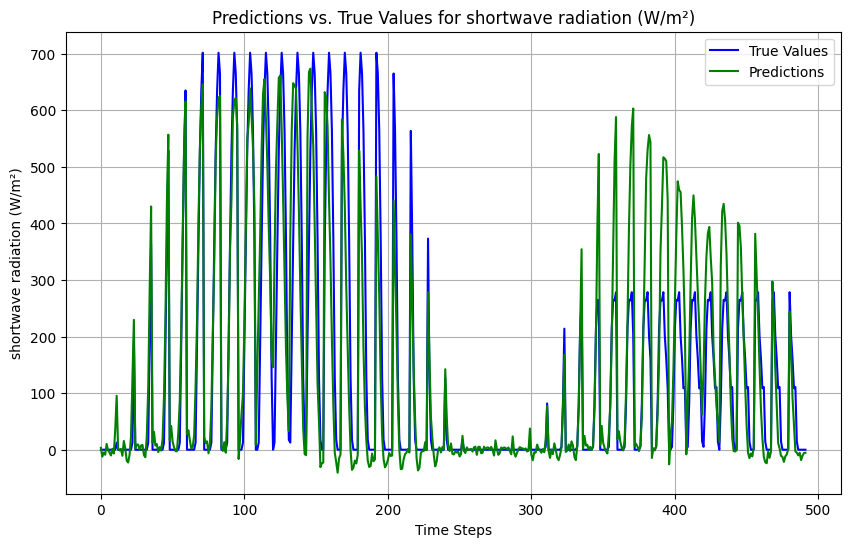

In [22]:
# prompt: plot the prediction vs true test

# Plot the predictions vs. true values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='True Values', color='blue')
plt.plot(y_pred, label='Predictions', color='green')
plt.title('Predictions vs. True Values for shortwave radiation (W/m²)')
plt.xlabel('Time Steps')
plt.ylabel('shortwave radiation (W/m²)')
plt.legend()
plt.grid(True)
plt.show()

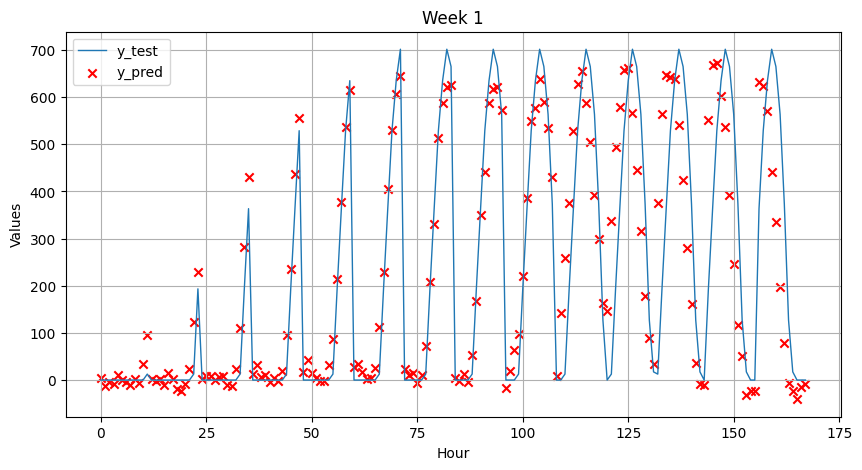

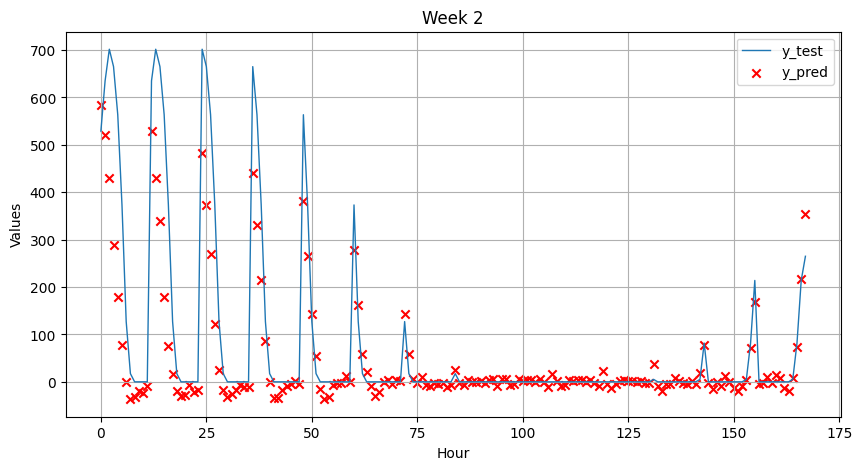

In [23]:
hours_per_week = 24 * 7

num_weeks = len(y_pred) // hours_per_week

for week in range(num_weeks):
    start_idx = week * hours_per_week
    end_idx = start_idx + hours_per_week
    plt.figure(figsize=(10, 5))  # Set ukuran figure
    plt.plot(y_test[start_idx:end_idx], label='y_test', linewidth=1)
    plt.scatter(range(hours_per_week), y_pred[start_idx:end_idx], color='red', marker='x', label='y_pred')
    plt.title(f'Week {week + 1}')
    plt.xlabel('Hour')
    plt.ylabel('Values')
    plt.legend()
    plt.grid(True)
    plt.show()